# Linear Algebra Practice

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Column space, null space, rank

In [ ]:
def generate_rank_matrix(m, n, r, seed=None):
    if m > r or n > r:
        raise "Rank must be less than or equal to m and n"
    rng = np.random.default_rng(seed)
    while True:
        U = rng.normal(size=(m, r)) * rng.integers(1, 4)
        V = rng.normal(size=(r, n)) * rng.integers(1,4)
        A = U @ V
        if np.linalg.matrix_rank(A) == r:
            return A
A = generate_rank_matrix(3,2,2)

In [3]:
def rref(A, tol=1e-12, ignore_last=False):
    A = A.astype(float).copy()
    pivots = []
    row = 0
    m, n = A.shape

    for c in range(n):
        if ignore_last and c == n - 1:
            continue

        # find pivot row
        pivot = None
        for r in range(row, m):
            if abs(A[r, c]) > tol:
                pivot = r
                break
        if pivot is None:
            continue

        if pivot != row:
            A[[row, pivot]] = A[[pivot, row]]

        A[row] = A[row] / A[row, c]

        for r in range(m):
            if r != row:
                A[r] -= A[row] * A[r, c]

        pivots.append(c)   
        row += 1
        if row == m:      
            break

    A[np.abs(A) < tol] = 0.0
    return A, np.array(pivots)


R, pivots = rref(A.copy())                

In [4]:
def build_nullspace(R, pivots, tol=1e-12):
    R = R.astype(float)
    m, n = R.shape
    pivots = list(pivots)

    free_cols = [j for j in range(n) if j not in pivots]
    f = len(free_cols)

    if f == 0:
        return np.zeros((n, 0))

    N = np.zeros((n, f))
    for k, free_j in enumerate(free_cols):
        x = np.zeros(n)
        x[free_j] = 1.0
        for i, pivot_j in enumerate(pivots):
            x[pivot_j] = -R[i, free_j]
        N[:, k] = x

    N[np.abs(N) < tol] = 0.0
    return N



N = build_nullspace(A.copy(), pivots)
print(N)

[]


In [5]:
def column_basis(A, pivots):
    return A[:, pivots]
column_basis(A.copy(), pivots)

array([[-25.77527402,   7.77652969],
       [  8.23493241,   2.29810449],
       [ -5.54155159,  -6.07372056]])

In [6]:
def compute_solution(A, b, tol=1e-12):
    A = A.astype(float)
    b = b.astype(float)

    m, n = A.shape
    Aug = np.column_stack([A, b])

    R_aug, pivots = rref(Aug, tol=tol, ignore_last=True)
    R = R_aug[:, :n]
    rhs = R_aug[:, n]

    for i in range(m):
        if np.all(np.abs(R[i]) < tol) and abs(rhs[i]) > tol:
            return np.zeros((n, 0)), "none"

    x_p = np.zeros(n)
    for i, pcol in enumerate(pivots):
        x_p[pcol] = rhs[i]

    N = build_nullspace(R, pivots, tol)

    if N.shape[1] == 0:
        return x_p, "unique"
    else:
        return np.column_stack([x_p, N]), "infinite"
b = np.sum(column_basis(A.copy(), pivots), axis=1)
compute_solution(A.copy(), b)

(array([1., 1.]), 'unique')

### Projections

In [7]:
def compute_projections(a, b):
    numerator = np.dot(a.T, b)
    denominator = np.dot(a.T, a)
    x = numerator/denominator
    p = a * x
    return p
a = np.random.uniform(0, 10, size=3)
b = np.random.uniform(0, 10, size=3)
p = compute_projections(a,b)
ortho = np.dot((b-p), a)
print(p, ortho.round(10))

[ 6.46170802 11.50492747  3.20725945] -0.0


In [8]:
def compute_projection_matrix(A):
    _, pivots = rref(A.copy())
    A = A[:, pivots]
    inverse = np.linalg.inv(A.T @ A)
    P = A @ inverse @ A.T
    P[np.abs(P) < 1e-12] = 0.0
    return P

b = np.random.uniform(0, 10, size=A.shape[0])
P = compute_projection_matrix(A.copy())
projection = P @ b
print("Projection matrix P:")
print(P)
print("\nProjection of b onto column space of A:")
print(projection)
# Verify idempotent property of projection matrix
print("P @ P == P:", np.allclose(P @ P, P))

# Check orthogonality: A^T * (projection - b) should be zero
orthogonal_check = A.T @ (projection - b)
print("\nA^T * (projection - b):")
print(orthogonal_check)
print("Is orthogonal (close to zero):", np.allclose(orthogonal_check, 0))

Projection matrix P:
[[ 0.97537558 -0.13186562 -0.08142184]
 [-0.13186562  0.29384968 -0.43602007]
 [-0.08142184 -0.43602007  0.73077474]]

Projection of b onto column space of A:
[ 6.02229326 -0.11863099 -1.62919586]
P @ P == P: True

A^T * (projection - b):
[ 1.42108547e-14 -1.06581410e-14]
Is orthogonal (close to zero): True


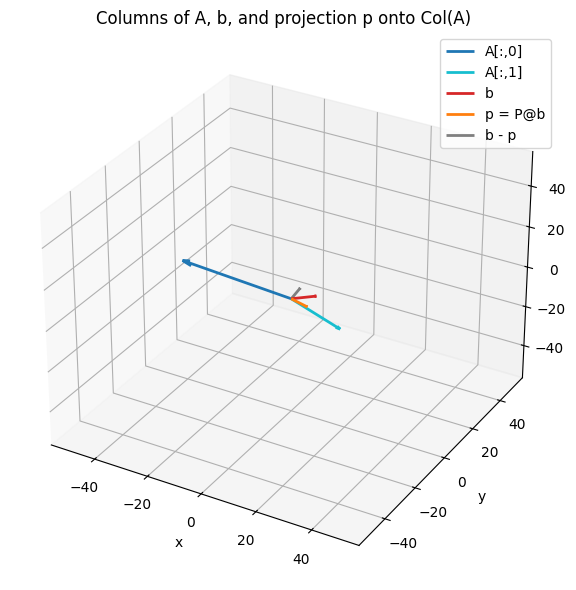

In [9]:

# Columns of A (each is a vector in R^3)
a_cols = [A[:, j] for j in range(A.shape[1])]

# b and its projection p onto Col(A)
p = projection  # or: p = P @ b

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

def draw_vec(v, color, label):
    ax.quiver(0, 0, 0, v[0], v[1], v[2],
              color=color, arrow_length_ratio=0.08, linewidth=2, label=label)

a_cols = [v * 2 for v in a_cols]
colors = ["tab:blue", "tab:cyan", "tab:purple", "tab:green"]
for j, v in enumerate(a_cols):
    draw_vec(v, colors[j % len(colors)], f"A[:,{j}]")

# draw b, projection p, and the residual (b - p)
draw_vec(b, "tab:red", "b")
draw_vec(p, "tab:orange", "p = P@b")
draw_vec(b - p, "tab:gray", "b - p")

# Set axis limits nicely
all_vecs = np.column_stack(a_cols + [b, p, b - p])
m = np.max(np.abs(all_vecs))
lim = 1.1 * (m if m > 0 else 1.0)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Columns of A, b, and projection p onto Col(A)")
ax.legend()
plt.tight_layout()
plt.show()

### Least Squares

In [10]:
def least_squares(A, b):
    b_hat = A.T @ b
    A_square = A.T @ A
    sol, status = compute_solution(A_square, b_hat)
    if status == "none":
        raise ValueError("Normal equations reported inconsistent (should not happen in exact arithmetic).")
    if status == "unique":
        x_hat = sol
    else: 
        x_hat = sol[:, 0] 
    return x_hat
# Generate a new overdetermined system for least squares (e.g., 4 equations, 2 variables)
new_A = generate_rank_matrix(4, 1, 1, seed=42)
new_A = np.column_stack([np.ones(4), new_A])
new_b = np.random.uniform(0, 10, size=4)

# Compute least squares solution
x_hat = least_squares(new_A, new_b)
print("Least squares solution x_hat:")
print(x_hat)
p = new_A @ x_hat
print(f"Projection of b on to Col(A): {p}")
e = new_b - p
ortho = new_A.T @ e
print("Ortho:", ortho)
print("Is ortho close to zero:", np.allclose(ortho, 0))

Least squares solution x_hat:
[ 4.92725146 -1.39515366]
Projection of b on to Col(A): [5.48084332 3.03787021 6.29062654 6.63601347]
Ortho: [ 1.77635684e-15 -6.66133815e-16]
Is ortho close to zero: True


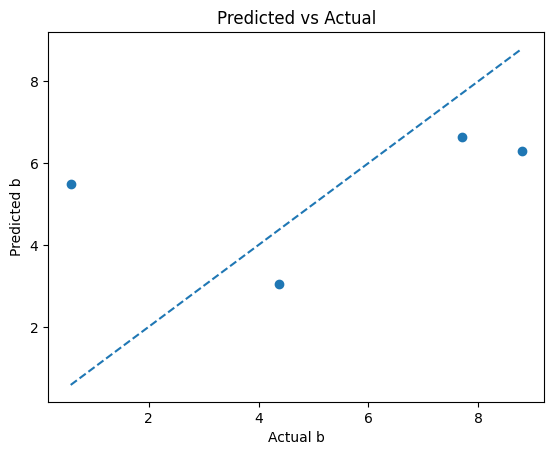

In [11]:
b_pred = new_A @ x_hat
plt.scatter(new_b, b_pred)
plt.xlabel("Actual b")
plt.ylabel("Predicted b")
plt.title("Predicted vs Actual")
plt.plot([new_b.min(), new_b.max()], [new_b.min(), new_b.max()], '--')  # y=x reference
plt.show()

### Eigenvectors and Eigenvalues

In [12]:
A = np.array([[2, 1],
              [1, 1]], float)
x0 = np.array([0, 1])
steps = 1000
angles = []
estimates = []
y = x0
for i in range(steps):
    y = A@y
    y = y / np.linalg.norm(y)
    angle = np.arctan2(y[1], y[0])
    angles.append(angle)
    lambda_k = (y @ (A @ y)) / (y @ y) 
    estimates.append(lambda_k)

In [13]:
lambda_true = max(np.linalg.eig(A)[0])
x_true = np.linalg.eig(A)[1]

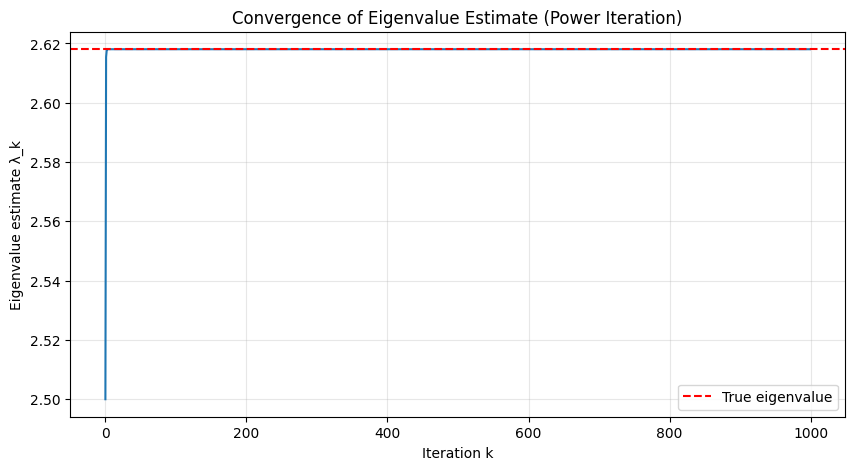

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(steps), estimates)
plt.xlabel('Iteration k')
plt.ylabel('Eigenvalue estimate λ_k')
plt.title('Convergence of Eigenvalue Estimate (Power Iteration)')
plt.grid(True, alpha=0.3)
plt.axhline(y=lambda_true, color='r', linestyle='--', label='True eigenvalue')
plt.legend()
plt.show()


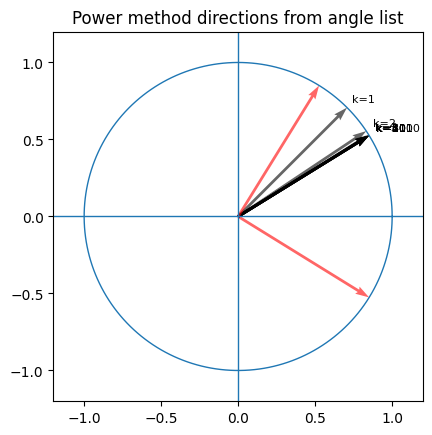

In [15]:

angles_arr = np.array(angles)          # shape (steps,)
U = np.cos(angles_arr)                 # x-components
V = np.sin(angles_arr)                 # y-components

# pick a few angles to draw
idxs = [0, 1, 2, 3, 5, 10, 20, 50, 100, 300, 999]
idxs = [i for i in idxs if i < len(angles_arr)]

# unit circle for reference
t = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(t), np.sin(t), linewidth=1)

for i in idxs:
    plt.quiver(0, 0, U[i], V[i],
               angles='xy', scale_units='xy', scale=1, alpha=0.6)
    plt.text(U[i]*1.05, V[i]*1.05, f"k={i+1}", fontsize=8)
plt.quiver([0, 0], 0, x_true[:, 0], x_true[:, 1],
               angles='xy', scale_units='xy', scale=1, alpha=0.6, color="red")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.title("Power method directions from angle list")
plt.show()

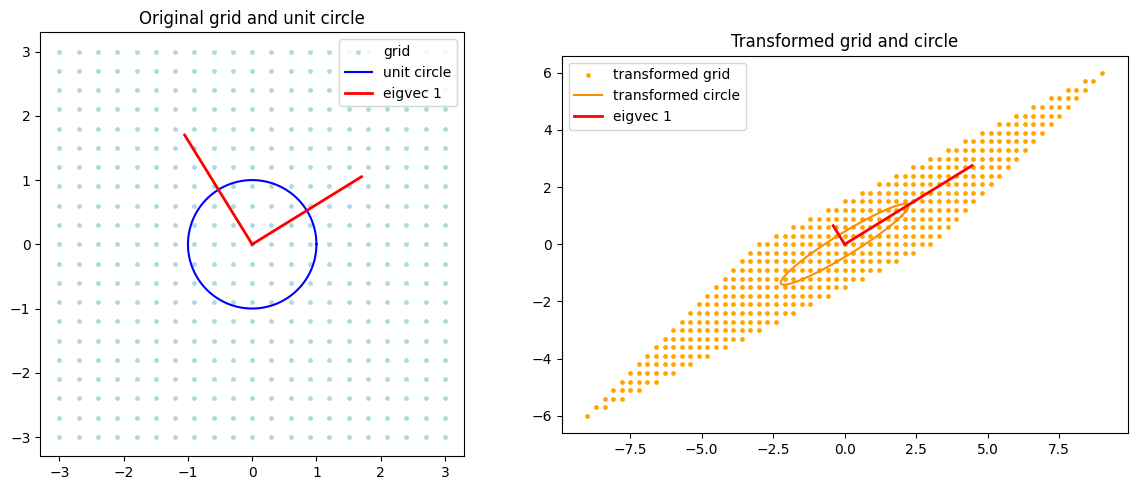

In [16]:
# 1) make a grid of points and unit circle
grid_n = 21
lims = (-3, 3)
xs = np.linspace(lims[0], lims[1], grid_n)
ys = np.linspace(lims[0], lims[1], grid_n)
xx, yy = np.meshgrid(xs, ys)
pts = np.vstack([xx.ravel(), yy.ravel()]).T

t = np.linspace(0, 2*np.pi, 300)
circle = np.vstack([np.cos(t), np.sin(t)]).T

# 2) apply A to every point and the circle
A_pts = (A @ pts.T).T
A_circle = (A @ circle.T).T

# 3) compute eigenvectors with np.linalg.eig(A)
vals, vecs = np.linalg.eig(A)
vecs_unit = vecs / np.linalg.norm(vecs, axis=0)

# 4) plot original and transformed with eigenvector directions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original space
ax = axes[0]
ax.scatter(pts[:,0], pts[:,1], s=6, color='lightblue', label='grid')
ax.plot(circle[:,0], circle[:,1], color='blue', label='unit circle')
for i in range(vecs_unit.shape[1]):
    v = vecs_unit[:, i]
    ax.plot([0, v[0]*2], [0, v[1]*2], color='red', linewidth=2,
            label=f'eigvec {i+1}' if i==0 else None)
ax.set_title('Original grid and unit circle')
ax.set_aspect('equal', 'box')
ax.legend()

# Transformed space
ax = axes[1]
ax.scatter(A_pts[:,0], A_pts[:,1], s=6, color='orange', label='transformed grid')
ax.plot(A_circle[:,0], A_circle[:,1], color='darkorange', label='transformed circle')
for i in range(vecs_unit.shape[1]):
    v = vecs_unit[:, i]
    lv = vals[i]
    # A @ v = lambda * v so direction is the same; scale by eigenvalue for visibility
    ax.plot([0, v[0]*lv*2], [0, v[1]*lv*2], color='red', linewidth=2,
            label=f'eigvec {i+1}' if i==0 else None)
ax.set_title('Transformed grid and circle')
ax.set_aspect('equal', 'box')
ax.legend()

plt.tight_layout()
plt.show()

#### Eigen diagonalization

In [17]:
A = generate_rank_matrix(2, 2, 2)
w, V = np.linalg.eig(A)

# reconstruct A
A_hat = V @ np.diag(w) @ np.linalg.inv(V)
print("A_hat ≈ A:", np.allclose(A_hat, A, atol=1e-8))

# pick exponent
n = 50

# compute A^n by repeated multiplication
A_n = np.eye(2, dtype=complex)
for _ in range(n):
    A_n = A_n @ A

# compute A^n by diagonalization
A_n_hat = V @ np.diag(w**n) @ np.linalg.inv(V)

print("A^n ≈ A^n_hat:", np.allclose(A_n, A_n_hat, atol=1e-6))
print("error norm:", np.linalg.norm(A_n - A_n_hat))

A_hat ≈ A: True
A^n ≈ A^n_hat: True
error norm: 2.0867516269008288e-22


### Applied Eigenvalues + Eigenvectors

In [18]:
A = np.array([[0.92, 0.1], [0.08, 0.9]])
x, V = np.linalg.eig(A)
x0_1 = np.array([1, 0])
x0_2 = np.array([0, 1])
print("Eigenvalues:")
print(x)
print("\nEigenvectors:")
print(V)

Eigenvalues:
[1.   0.82]

Eigenvectors:
[[ 0.78086881 -0.70710678]
 [ 0.62469505  0.70710678]]


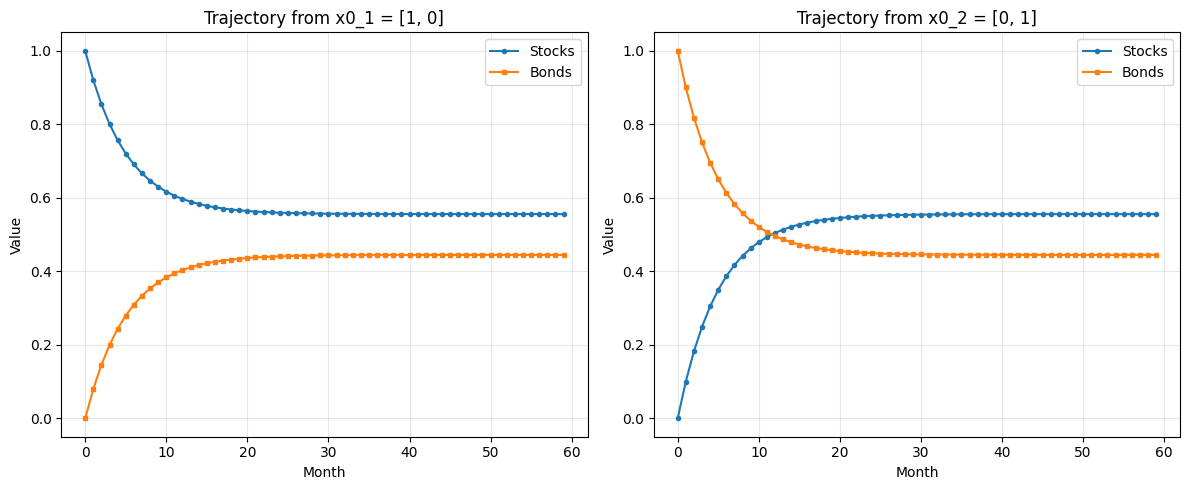

In [19]:
# Simulate x_{t+1} = A*x_t for 60 months
months = 60
trajectory_1 = np.zeros((months, 2))
trajectory_2 = np.zeros((months, 2))

x_current_1 = x0_1.copy()
x_current_2 = x0_2.copy()

for t in range(months):
    trajectory_1[t] = x_current_1
    trajectory_2[t] = x_current_2
    x_current_1 = A @ x_current_1
    x_current_2 = A @ x_current_2

# Plot both trajectories
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trajectory_1[:, 0], label='Stocks', marker='o', markersize=3)
plt.plot(trajectory_1[:, 1], label='Bonds', marker='s', markersize=3)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Trajectory from x0_1 = [1, 0]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(trajectory_2[:, 0], label='Stocks', marker='o', markersize=3)
plt.plot(trajectory_2[:, 1], label='Bonds', marker='s', markersize=3)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Trajectory from x0_2 = [0, 1]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
def A_n(S, x, n):
    X = np.diag(x**n)
    return S @ X @ np.linalg.inv(S)
    # Using eigenvalue diagonalization from cell 24
A_60_diag = A_n(V, x, 60)

# Compute trajectories using diagonalization
x_60_1 = A_60_diag @ x0_1
x_60_2 = A_60_diag @ x0_2

print("State after 60 months from x0_1 using diagonalization:")
print(x_60_1)
print("\nState after 60 months from x0_2 using diagonalization:")
print(x_60_2)

# Compare with iterative method
print("\nComparison with iterative method:")
print("x0_1: Iterative =", trajectory_1[-1], "Diag =", x_60_1)
print("x0_2: Iterative =", trajectory_2[-1], "Diag =", x_60_2)
print("Close match:", np.allclose(trajectory_1[-1], x_60_1) and np.allclose(trajectory_2[-1], x_60_2))

State after 60 months from x0_1 using diagonalization:
[0.55555855 0.44444145]

State after 60 months from x0_2 using diagonalization:
[0.55555181 0.44444819]

Comparison with iterative method:
x0_1: Iterative = [0.55555921 0.44444079] Diag = [0.55555855 0.44444145]
x0_2: Iterative = [0.55555099 0.44444901] Diag = [0.55555181 0.44444819]
Close match: True


## Mini Project for Unit 2

### Least Squares

In [21]:
t = np.random.randint(1, 10, size=10)
y = 0.3 * t + 2 + np.random.normal(size=10)
print(f"t: {t} y: {y}")

t: [5 8 4 3 2 5 6 8 3 3] y: [3.43205267 5.34954293 4.66065379 2.08383751 1.73648381 4.14496738
 4.24356603 2.31494985 3.24036863 2.49960779]


In [22]:
A = np.column_stack([t, np.ones_like(t)])
x_hat = least_squares(A.copy(), y.copy())

In [23]:
p = A @ x_hat
e = y - p
print(f"e: {e}")
print(f"p: {p}")

e: [-0.02706249  1.00530654  1.49657903 -0.78519683 -0.83751013  0.68585222
  0.48941046 -2.02928654  0.37133429 -0.36942655]
p: [3.45911516 4.34423639 3.16407475 2.86903434 2.57399393 3.45911516
 3.75415557 4.34423639 2.86903434 2.86903434]


In [24]:
result = A.T @ e
print(f"A @ e = {result}")
print(f"Is A @ e close to zero? {np.allclose(result, 0)}")

A @ e = [-2.66453526e-14 -2.22044605e-15]
Is A @ e close to zero? True


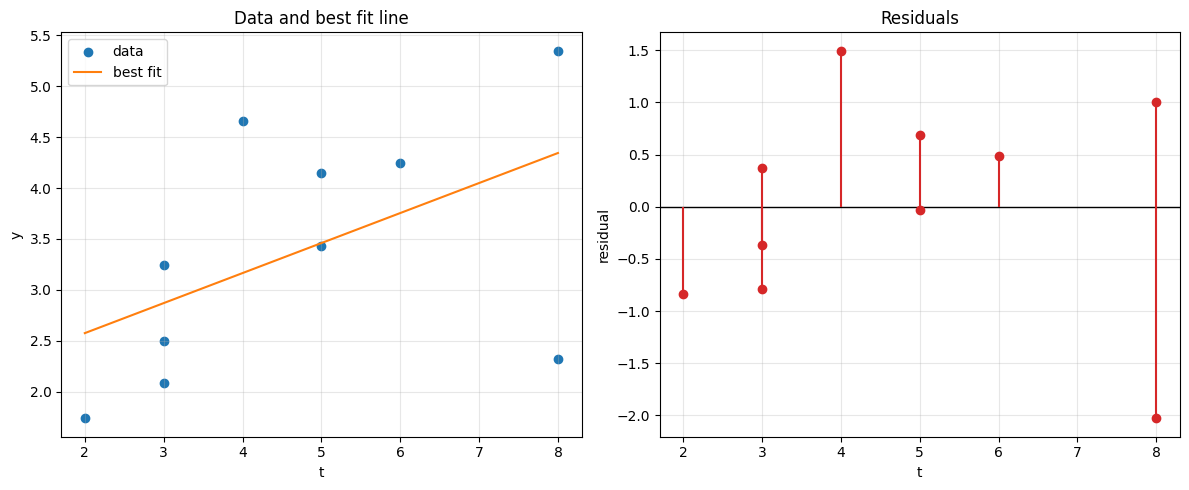

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(t, y, color="tab:blue", label="data")
t_sorted = np.argsort(t)
plt.plot(t[t_sorted], p[t_sorted], color="tab:orange", label="best fit")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Data and best fit line")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.axhline(0, color="black", linewidth=1)
plt.stem(t, e, linefmt="tab:red", markerfmt="o", basefmt=" ")
plt.xlabel("t")
plt.ylabel("residual")
plt.title("Residuals")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Compute determinants

In [26]:
x = np.random.randint(0,5, size=4)
A = np.column_stack([x, x*2])
print(A)

[[3 6]
 [1 2]
 [0 0]
 [4 8]]


In [27]:
def compute_determinant(A, tol=1e-12):
    det = 1
    row = 0
    A = A.copy()
    for c in range(len(A[0])):
        sign = 1
        #check which column has the pivot
        pivot = None
        for r in range(row, len(A)):
            if abs(A[r, c]) > tol:
                pivot = r
                break
        if pivot is None:
            det *= 0
            continue
        if pivot != row:
            A[[row, pivot]] = A[[pivot, row]]
            sign *= -1
        det *= sign * A[row][c]
        for r in range(len(A)):
            if r != row and A[r][c] != 0:
                A[r] -= A[row] * (A[r][c]/A[row][c])
        row += 1
        if row == len(A[0]):
            break
    return det
# Tests for compute_determinant
test_mats = [
    np.eye(3),
    np.array([[1, 2], [3, 4]], float),
    np.array([[0, 1], [2, 3]], float),
    np.array([[2, 0, 0], [0, 3, 0], [0, 0, 4]], float),
    generate_rank_matrix(3, 3, 3, seed=123),
    np.array([[1, 2], [2, 4]], float),  # singular matrix
]

for M in test_mats:
    det_expected = np.linalg.det(M)
    det_computed = compute_determinant(M.copy())
    assert np.allclose(det_computed, det_expected, atol=1e-8), (det_computed, det_expected)

print("compute_determinant tests passed.")

compute_determinant tests passed.


In [28]:
A_square = A.T @ A
print(A_square)
det = compute_determinant(A_square.copy().astype(float))
print(f"Determinat: {det}")

[[ 26  52]
 [ 52 104]]
Determinat: 0.0


### Eigenvalues of 2 state system
**Scenario**: A simple 2-state system models “money flows” between two buckets (stocks/bonds, cash/invested, users in two categories).

In [29]:
A = np.array([[0.82, 0.15], [0.18, 0.85]])
x0_1 = np.array([0, 1])
x0_2 = np.array([1, 0])

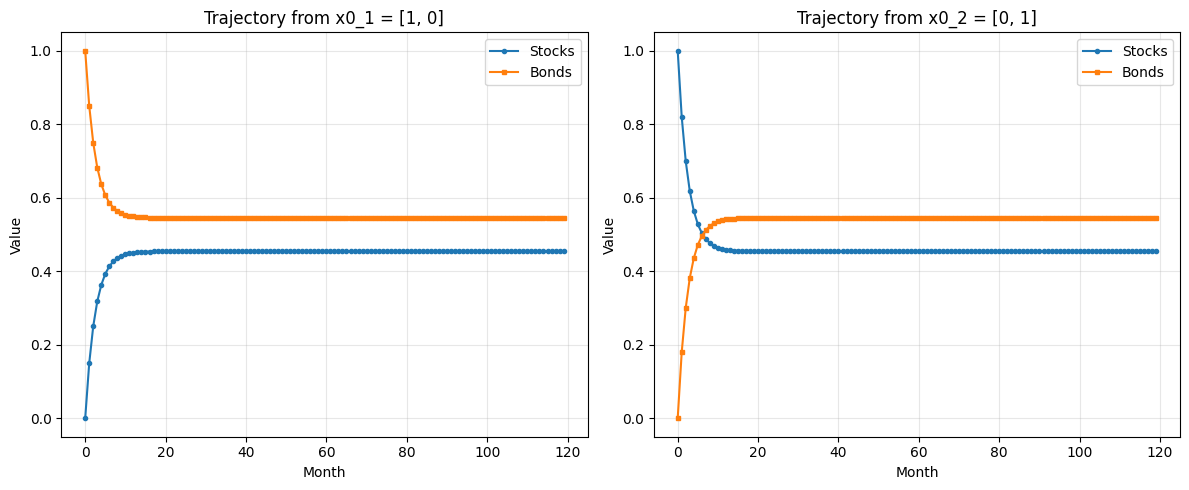

In [30]:
# Simulate x_{t+1} = A*x_t for 60 months
months = 120
trajectory_1 = np.zeros((months, 2))
trajectory_2 = np.zeros((months, 2))

x_current_1 = x0_1.copy()
x_current_2 = x0_2.copy()

for t in range(months):
    trajectory_1[t] = x_current_1
    trajectory_2[t] = x_current_2
    x_current_1 = A @ x_current_1
    x_current_2 = A @ x_current_2

# Plot both trajectories
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trajectory_1[:, 0], label='Stocks', marker='o', markersize=3)
plt.plot(trajectory_1[:, 1], label='Bonds', marker='s', markersize=3)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Trajectory from x0_1 = [1, 0]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(trajectory_2[:, 0], label='Stocks', marker='o', markersize=3)
plt.plot(trajectory_2[:, 1], label='Bonds', marker='s', markersize=3)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Trajectory from x0_2 = [0, 1]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
x, V = np.linalg.eig(A)
print(f"Eigenvalues: {x}")
print(f"Eigenvectors:\n{V}")

Eigenvalues: [0.67 1.  ]
Eigenvectors:
[[-0.70710678 -0.6401844 ]
 [ 0.70710678 -0.76822128]]


In [32]:
lambda_n = A_n(V, x, months)
steady_state1 = lambda_n @ x0_1
steady_state2 = lambda_n @ x0_2
print(f"Steady state from x0_1 = [0, 1]:\n{steady_state1}")
print(f"\nSteady state from x0_2 = [1, 0]:\n{steady_state2}")
print(f"\nTrajectory endpoint from loop x0_1:\n{trajectory_1[-1]}")
print(f"\nTrajectory endpoint from loop x0_2:\n{trajectory_2[-1]}")


Steady state from x0_1 = [0, 1]:
[0.45454545 0.54545455]

Steady state from x0_2 = [1, 0]:
[0.45454545 0.54545455]

Trajectory endpoint from loop x0_1:
[0.45454545 0.54545455]

Trajectory endpoint from loop x0_2:
[0.45454545 0.54545455]


### Fast power using diagonalization

In [33]:
A = generate_rank_matrix(2, 2, 2)
x, V = np.linalg.eig(A)
x0 = np.array([1, 0])

In [34]:
steps = 60
current = x0.copy()
for step in range(steps):
    current = A @ current
print(current)

[1.22484046e+40 4.60738143e+39]


In [35]:
A_n_hat = A_n(V, x, steps)
A_n_hat = A_n_hat @ x0
print("A^n_hat @ x0 ≈ current:", np.allclose(A_n_hat, current))

A^n_hat @ x0 ≈ current: True


### Symmetric Positive Definite

In [36]:
def is_spd(A):
    x, V = np.linalg.eig(A)
    if not np.all(x > 0):
        return False, "At least one eigenvalue is less than or equal to 0"
    m = A.shape[0]
    for i in range(1, m+ 1):
        det = compute_determinant(A[:i,:i])
        if det <= 0:
            return False, "At least one of the determinants is less than or equal to 0"
    return True, "The matrix is positive definite"
A_spd = np.array([[2, 6], [6, 20]], float)
is_spd(A_spd)

(True, 'The matrix is positive definite')

### Fourier Transforms

In [37]:
def dft(x):
    x = np.asarray(x, dtype=complex)
    n = x.size
    k = np.arange(n)
    F = np.exp(-2j * np.pi * np.outer(k, k) / n)    # negative sign = forward DFT
    return F @ x
x = np.array([1, 0, 0, 0])
dft(x)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [38]:
def fft(x):
    x = np.asarray(x, dtype=complex)
    n = x.size
    if n == 1:
        return x
    if n % 2 != 0:
        raise ValueError("n must be a power of two")
    even = fft(x[::2])
    odd  = fft(x[1::2])
    tw = np.exp(-2j * np.pi * np.arange(n//2) / n)  
    top = even + tw * odd
    bot = even - tw * odd
    return np.concatenate([top, bot])

x = np.array([1, 0, 0, 0])
fft(x)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [39]:
import time

# Generate test signals of different sizes
sizes = [8, 256, 512, 1024]
results = []

for size in sizes:
    xs = np.random.randn(size)
    
    # Time DFT
    start = time.time()
    dft_result = dft(xs)
    dft_time = time.time() - start
    
    # Time FFT
    start = time.time()
    fft_result = fft(xs)
    fft_time = time.time() - start
    
    # Time numpy FFT
    start = time.time()
    np_fft_result = np.fft.fft2(np.eye(size)) @ xs
    np_fft_time = time.time() - start
    # Check correctness
    is_correct = np.allclose(dft_result, fft_result, atol=1e-10)
    
    results.append({
        'dft_result': dft_result,
        'fft_result': fft_result,
        'np_fft_result': np_fft_result
    })
    
    print(f"Size {size}:")
    print(f"  DFT time: {dft_time:.6f}s")
    print(f"  FFT time: {fft_time:.6f}s")
    print(f"  numpy FFT time: {np_fft_time:.6f}s")
    print(f"  Speedup: {dft_time / fft_time:.2f}x")
    print(f"  Results match: {is_correct}\n")

Size 8:
  DFT time: 0.000059s
  FFT time: 0.000056s
  numpy FFT time: 0.040909s
  Speedup: 1.05x
  Results match: True

Size 256:
  DFT time: 0.002850s
  FFT time: 0.001546s
  numpy FFT time: 0.001179s
  Speedup: 1.84x
  Results match: True

Size 512:
  DFT time: 0.007067s
  FFT time: 0.002704s
  numpy FFT time: 0.004397s
  Speedup: 2.61x
  Results match: True

Size 1024:
  DFT time: 0.026666s
  FFT time: 0.005476s
  numpy FFT time: 0.018335s
  Speedup: 4.87x
  Results match: True



### Positive definit + minima

In [40]:
def generate_spd(n=3, eps=1e-6, seed=None):
    rng = np.random.default_rng(seed)
    B = rng.standard_normal((n, n))
    A = B.T @ B + eps * np.eye(n)
    return A
n = 3
A = generate_spd(n)
b = np.random.randn(3)

x_sol = compute_solution(A, b)[0]

In [41]:
def gradient_descent(A, b, lr=0.1, iterations=10000):
    x = np.random.random(b.shape)
    xs = []
    for i in range(iterations):
        x -= lr * (A @ x - b)
        xs.append(x.copy())
    return x, np.array(xs)

final_x, xs = gradient_descent(A, b)
print(xs[:, 1])

[0.57175232 0.82220571 0.99917699 ... 2.8762818  2.8762818  2.8762818 ]


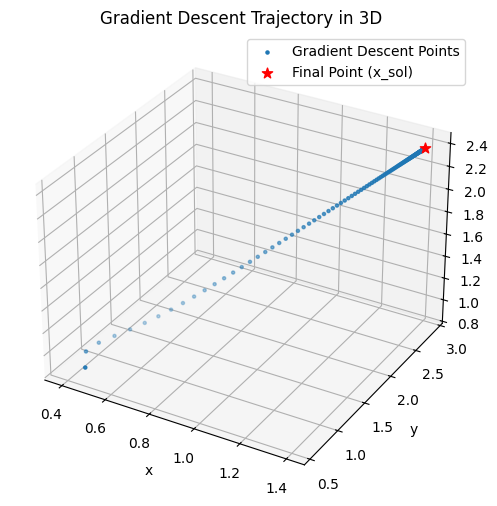

In [42]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xs[:, 0], xs[:, 1], xs[:, 2], s=5, label='Gradient Descent Points')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Gradient Descent Trajectory in 3D')
ax.legend()
# Add the final point from x_sol
ax.scatter(x_sol[0], x_sol[1], x_sol[2], color='red', s=60, label='Final Point (x_sol)', marker='*')
ax.legend()
plt.show()

### Similar and Jordan Matrices

In [43]:
n = 3
S = generate_rank_matrix(n, n, n)
A = generate_rank_matrix(n, n, np.random.randint(1, n))
B = np.linalg.inv(S) @ A @ S

In [44]:
eig_a, _ = np.linalg.eig(A)
eig_b, _ = np.linalg.eig(B)
det_a = compute_determinant(A)
det_b = compute_determinant(B)
trace_a = np.diag(A).sum()
trace_b = np.diag(B).sum()
print("Eigenvalues equal:", np.allclose(np.sort(eig_a), np.sort(eig_b)))
print("Determinants equal:", np.allclose(det_a, det_b))
print("Traces equal:", np.allclose(trace_a, trace_b))


Eigenvalues equal: True
Determinants equal: True
Traces equal: True


In [45]:
A = np.array([[1,1],
              [0,1]], float)
S = generate_rank_matrix(2, 2, 2)
B = np.linalg.inv(S) @ A @ S
eig_a, V_a = np.linalg.eig(A)
eig_b, V_b = np.linalg.eig(B)
print(eig_a, V_a)
print(eig_b, V_b)

[1. 1.] [[ 1.00000000e+00 -1.00000000e+00]
 [ 0.00000000e+00  2.22044605e-16]]
[1.+2.45135574e-09j 1.-2.45135574e-09j] [[-0.57342961-2.42372058e-08j -0.57342961+2.42372058e-08j]
 [ 0.81925483+0.00000000e+00j  0.81925483-0.00000000e+00j]]


### SVD

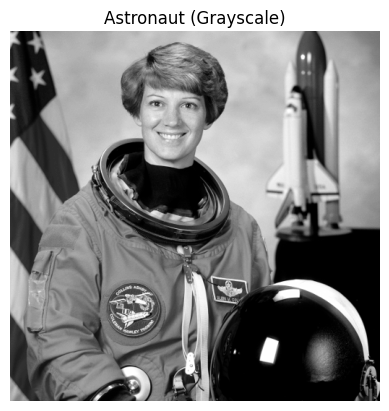

In [46]:
from matplotlib.image import imread

img = imread('astronaut.png')
if img.ndim == 3:
    # Convert to grayscale using luminosity method
    img_gray = img[..., 0]*0.2989 + img[..., 1]*0.5870 + img[..., 2]*0.1140
else:
    img_gray = img

plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.title('Astronaut (Grayscale)')
plt.show()

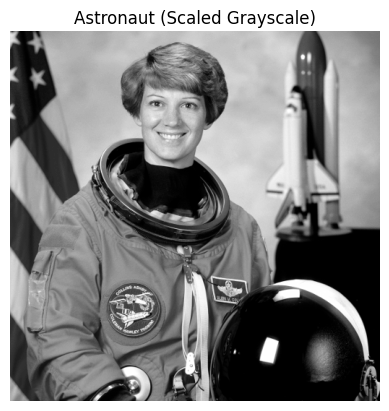

In [47]:
# Example: scale the grayscale image by dividing by its max value (normalization)
img_gray_scaled = img_gray / (img_gray.max() - img_gray.min())

plt.imshow(img_gray_scaled, cmap='gray')
plt.axis('off')
plt.title('Astronaut (Scaled Grayscale)')
plt.show()

In [ ]:
def compute_svd(A, tol=1e-12):
    A = A.astype(float)

    ATA = A.T @ A
    eigvals, V = np.linalg.eigh(ATA)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    V = V[:, idx]

    sing = np.sqrt(np.clip(eigvals, 0, None))

    r = np.sum(sing > tol)
    sing_r = sing[:r]
    V_r = V[:, :r]

    U_r = (A @ V_r) / sing_r

    Sigma_r = np.diag(sing_r)

    return U_r, Sigma_r, V_r.T
A = generate_rank_matrix(3, 3, 3)
U, Sigma, V = compute_svd(A)
# Compare with numpy's SVD
U_np, s_np, Vh_np = np.linalg.svd(A, full_matrices=False)
Sigma_np = np.diag(s_np)

print("U close to U_np:", np.allclose(np.abs(U), np.abs(U_np)))
print("Sigma close to Sigma_np:", np.allclose(Sigma, Sigma_np))
print("V close to Vh_np:", np.allclose(np.abs(V), np.abs(Vh_np)))
A_reconstructed = U @ Sigma @ V
print("A_reconstructed ≈ A:", np.allclose(A_reconstructed, A))

(3, 2) (2, 2) (2, 2)
U close to U_np: True
Sigma close to Sigma_np: True
V close to Vh_np: True
A_reconstructed ≈ A: True


In [49]:
ks = [5, 20, 50, 100, 200, 400, 512]
U, S, V = compute_svd(img_gray_scaled)
approximations = []
errors = []
for k in ks:
    # Take first k singular values/vectors
    Uk = U[:, :k]
    Sk = S[:k, :k]
    Vk = V[:k, :]
    Mk = Uk @ Sk @ Vk
    approximations.append(Mk)
    error = np.linalg.norm(img_gray_scaled - Mk)
    errors.append(error)
    print(f"K={k} Error={error}")


K=5 Error=78.93098827661733
K=20 Error=39.74555086248322
K=50 Error=21.75512559883099
K=100 Error=11.479769231382319
K=200 Error=4.285084821112679
K=400 Error=0.4955883994113776
K=512 Error=5.156794284391928e-13


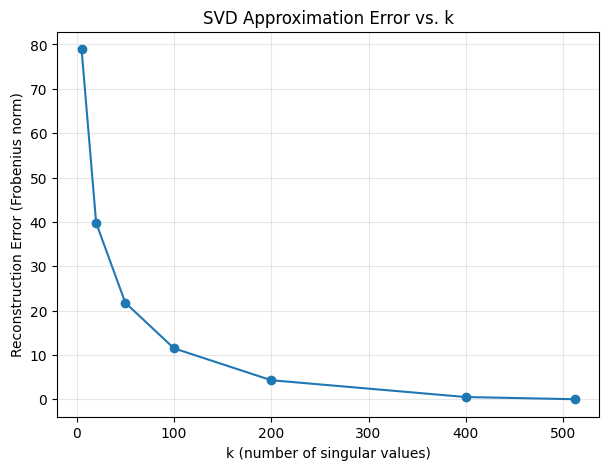

In [50]:
plt.figure(figsize=(7, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel('k (number of singular values)')
plt.ylabel('Reconstruction Error (Frobenius norm)')
plt.title('SVD Approximation Error vs. k')
plt.grid(True, alpha=0.3)
plt.show()

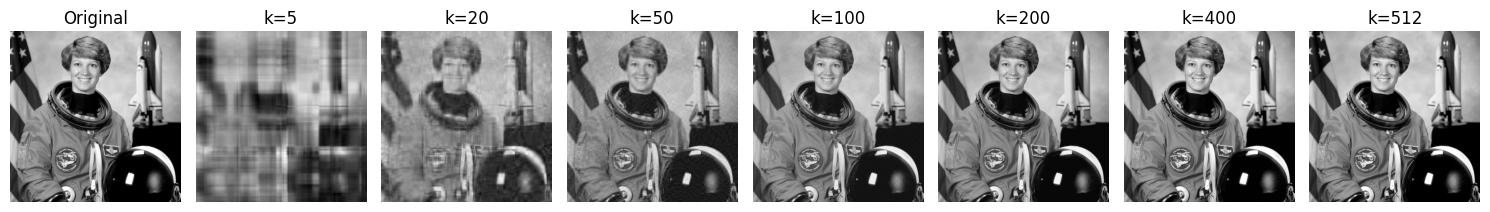

In [51]:
fig, axes = plt.subplots(1, len(approximations) + 1, figsize=(15, 5))

# Show original image
axes[0].imshow(img_gray_scaled, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Show approximations
for i, (k, Mk) in enumerate(zip(ks, approximations)):
    axes[i + 1].imshow(Mk, cmap='gray')
    axes[i + 1].set_title(f'k={k}')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()